In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import parismc
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")


# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 0.25     # Total time

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

print('Done initializing waveform generator.')

#Generating data (true)

# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0 #NOTE: fixed
dist = 0.5 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #NOTE: fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # NOTE: fixed
Phi_r0 = 0.5

print('Generating data signal...')
data = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
print('Done generating data signal.')
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, dist, np.cos(qS), Phi_phi0, Phi_r0]


print('Setting up GWFuncs...')
gwf = GWfuncs.GravWaveAnalysis(T, dt)
print('Done setting up GWFuncs.')

print('Setting up log-likelihood and prior...')
def loglike(params):

    params = np.asarray(params)

    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a, p0, e0, dist, cosqS, Phi_phi0, Phi_r0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2
        qS = np.arccos(cosqS)
        # phiK = phiS + np.pi/3

        htemp = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
                            Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt)
        

        res = data - htemp
        res_f = gwf.freq_wave(res)
        inner_res = gwf.inner(res_f, res_f)
        log_likes[i] = -0.5 * inner_res

    return log_likes

    
def prior_transform(u):
    # 3 sigma
    logm1lim = [5.9997559660034545, 6.0002440339965455]
    logm2lim = [1.4769870513067693, 1.4772554581325554]
    alim = [0.6995637359323849, 0.700436264067615]
    p0lim =  [7.497572969135001, 7.502427030864999]
    e0lim = [0.39989407441651065, 0.4001059255834894]
    distlim =  [0.48515728649322165, 0.5148427135067783]
    cosqSlim =  [0.8410565746295281, 0.9141085491512174]
    Phiphilim =  [0.29766594651745004, 0.50233405348255]
    Phirlim = [0.43749426805155983, 0.5625057319484402]

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Uniform for other parameters

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    # dist 
    transformed[:, 5] = (distlim[1] - distlim[0]) * u[:, 5] + distlim[0]

    # qS
    transformed[:, 6] = (cosqSlim[1] - cosqSlim[0]) * u[:, 6] + cosqSlim[0]

    # Phi_phi0
    transformed[:, 7] = (Phiphilim[1] - Phiphilim[0]) * u[:, 7] + Phiphilim[0]

    # Phi_r0
    transformed[:, 8] = (Phirlim[1] - Phirlim[0]) * u[:, 8] + Phirlim[0]

    
    return transformed


def inverse_prior_transform(x):
    logm1lim = [5.9997559660034545, 6.0002440339965455]
    logm2lim = [1.4769870513067693, 1.4772554581325554]
    alim = [0.6995637359323849, 0.700436264067615]
    p0lim =  [7.497572969135001, 7.502427030864999]
    e0lim = [0.39989407441651065, 0.4001059255834894]
    distlim =  [0.48515728649322165, 0.5148427135067783]
    cosqSlim =  [0.8410565746295281, 0.9141085491512174]
    Phiphilim =  [0.29766594651745004, 0.50233405348255]
    Phirlim = [0.43749426805155983, 0.5625057319484402]


    u = np.zeros_like(x)

    u[:, 0] = (x[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (x[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (x[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (x[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (x[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (x[:, 5] - distlim[0]) / (distlim[1] - distlim[0])
    u[:, 6] = (x[:, 6] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 7] = (x[:, 7] - Phiphilim[0]) / (Phiphilim[1] - Phiphilim[0])
    u[:, 8] = (x[:, 8] - Phirlim[0]) / (Phirlim[1] - Phirlim[0])
    
    return u


Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Generating data signal...
Done generating data signal.
Setting up GWFuncs...
Done setting up GWFuncs.
Setting up log-likelihood and prior...


In [2]:
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

In [4]:
sampler = parismc.Sampler.load_state('./paris_likelihoodteset_reduced/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
sampler.prior_transform(np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]))


array([[5.99975597, 1.47698705, 0.69956374, 7.49757297, 0.39989407,
        0.48515729, 0.84105657, 0.29766595, 0.43749427, 0.        ]])

In [6]:
sampler.prior_transform(np.array([[1.,1.,1.,1.,1.,1.,1.,1.,1.,1.]]))

array([[6.00024403, 1.47725546, 0.70043626, 7.50242703, 0.40010593,
        0.51484271, 0.91410855, 0.50233405, 0.56250573, 0.        ]])

In [14]:
param_ranges = [(5.9997559660034545, 6.0002440339965455),
                (1.4769870513067693, 1.4772554581325554),
                (0.6995637359323849, 0.700436264067615),
                (7.497572969135001, 7.502427030864999),
                (0.39989407441651065, 0.4001059255834894),
                (0.48515728649322165, 0.5148427135067783),
                (0.8410565746295281, 0.9141085491512174),
                (0.29766594651745004, 0.50233405348255),
                (0.43749426805155983, 0.5625057319484402)]

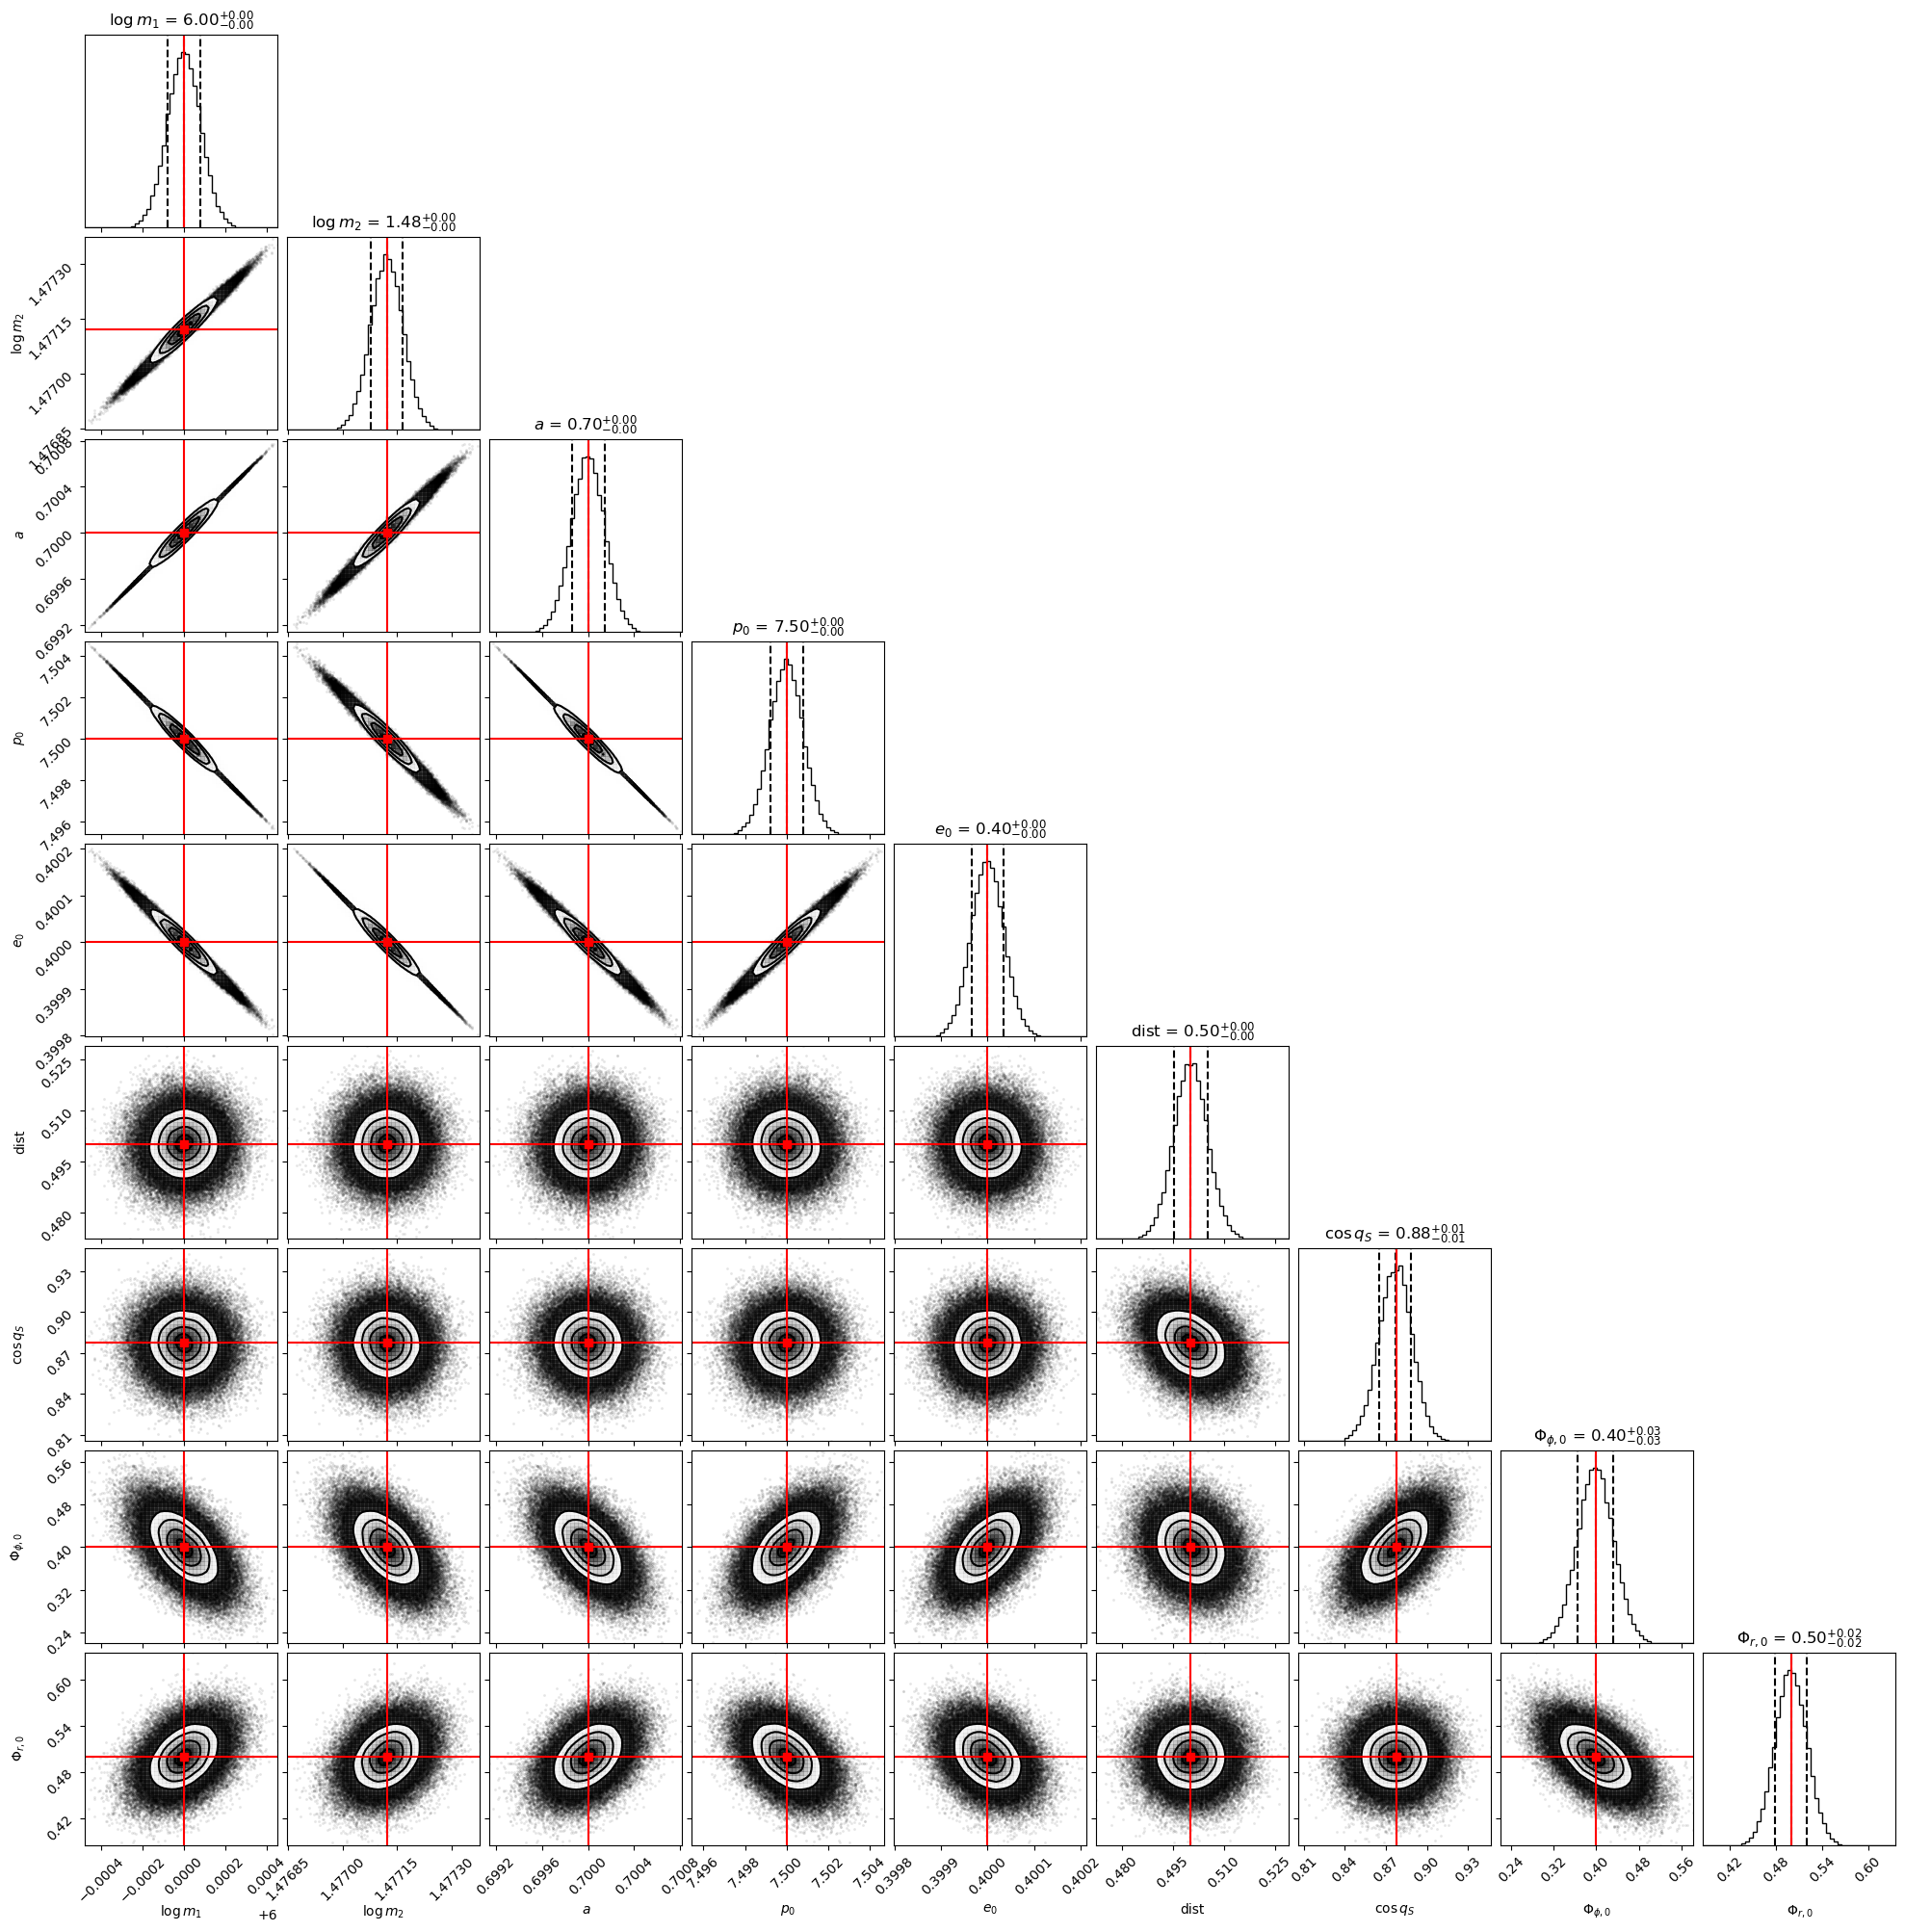

In [15]:
# try corner
import corner
labels = [r'$\log{m_1}$', r'$\log{m_2}$',r'$a$',r'$p_0$',r'$e_0$',r'dist',r'$\cos{q_S}$', 
        r'$\Phi_{\phi,0}$', r'$\Phi_{r,0}$']

fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84], 
    smooth=True,
    bins=50,
    ranges = param_ranges
)

In [12]:
import pickle
with open('cov_matrix_reduced.pkl', 'rb') as f:
    cov_matrix = pickle.load(f)


In [13]:
from scipy.stats import multivariate_normal

n_fisher_samples = 10000
fisher_samples = multivariate_normal.rvs(
    mean=param_true, 
    cov=cov_matrix,     
    size=n_fisher_samples
)

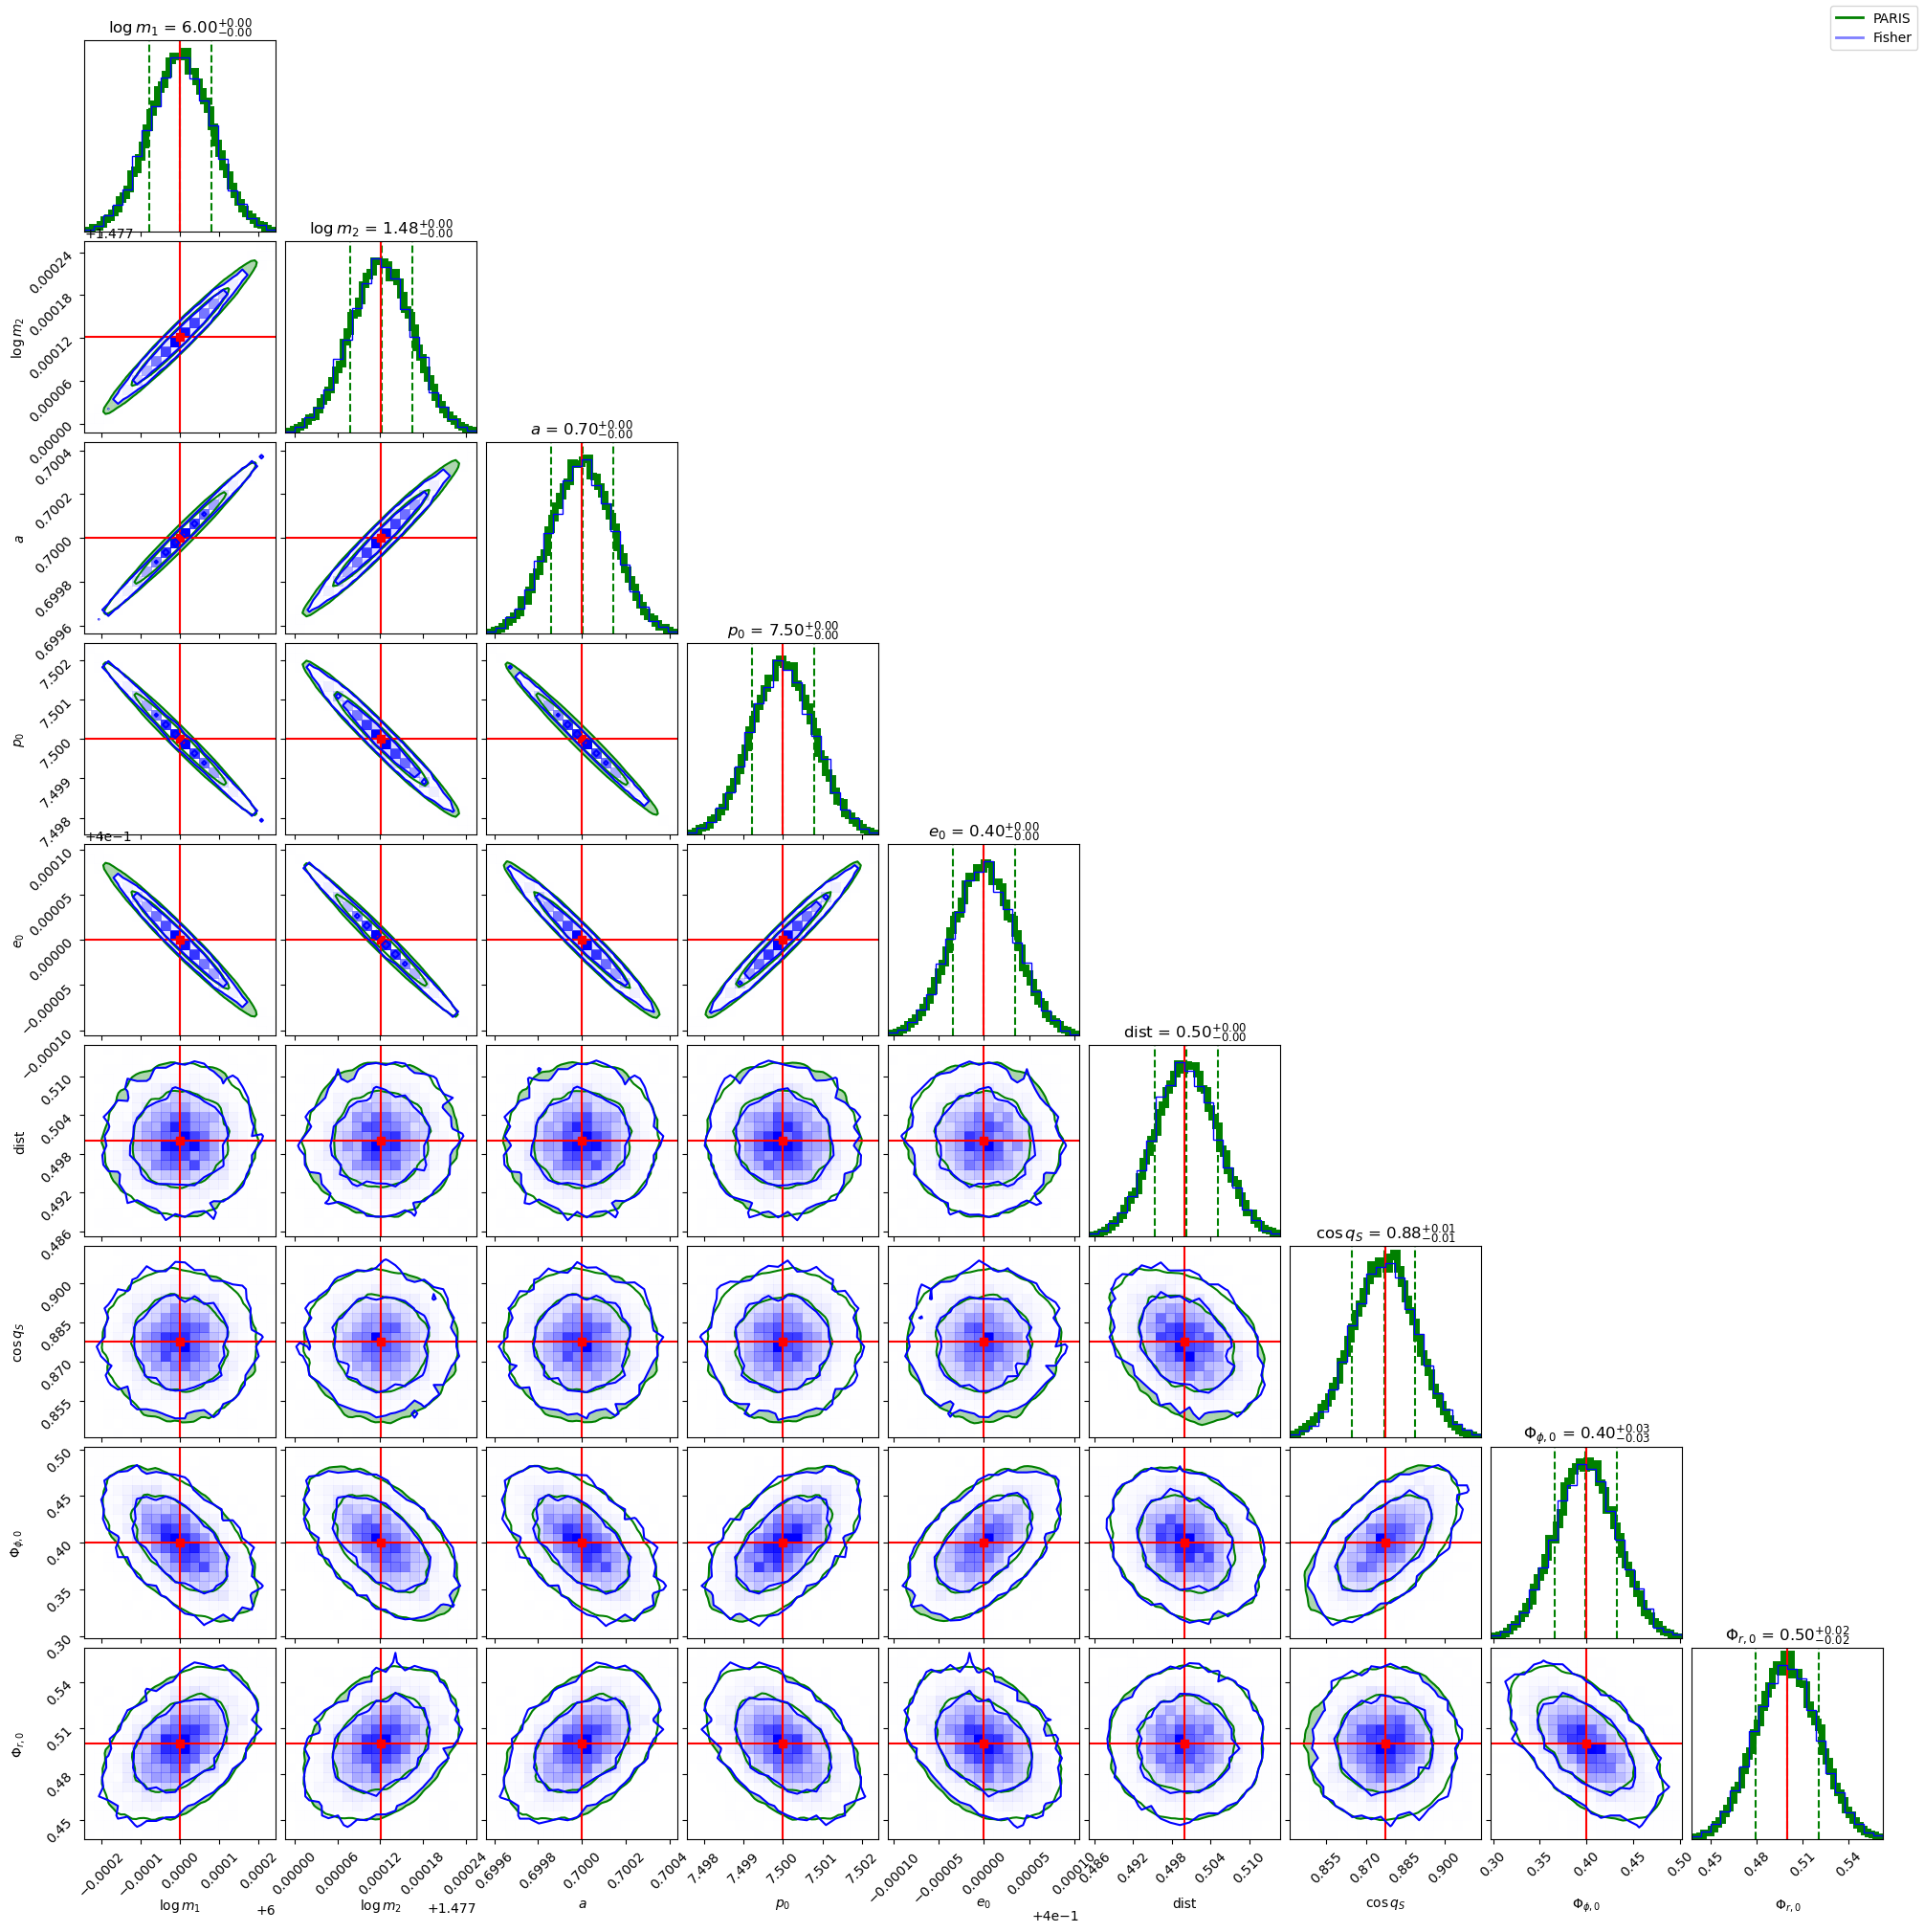

In [16]:
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=50,
    plot_datapoints=False,
    plot_density= True,
    levels=[0.68, 0.95],
    hist_kwargs={"density": True, 'linewidth': 5},
    linewidth=5,
    fill_contours=True,
    range = param_ranges
)


# Overlay Fisher ellipses
corner.corner(
    fisher_samples,
    fig=fig,
    color='blue',
    plot_datapoints=False,
    plot_density=True,
    levels=[0.68, 0.95],
    alpha=0.5,
    hist_kwargs={"density": True},
    range = param_ranges
)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='PARIS'),
    # Line2D([0], [0], color='red', lw=2, label='Dynesty'),
    Line2D([0], [0], color='blue', lw=2, label='Fisher', alpha=0.5)
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)